In [ ]:
# =========================
# 1. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Libraries installed
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All imports done
✅ Dataset shape: (597, 14)
✅ After cleaning: (575, 14)
Class distribution:
target
0    333
1    242
Name: count, dtype: int64
✅ Shape after feature engineering: (575, 26)
✅ After SMOTE: (666, 25), counts: [333 333]
✅ Selected features: ['sex', 'cp', 'thalach', 'exang', 'oldpeak', 'ca', 'thal', 'hr_reserve', 'oldpeak_slope', 'exang_cp', 'ca_thal', 'sex_cp', 'thalach_sq', 'oldpeak_sq']
✅ Train: (532, 14) | Test: (134, 14)

Model                       CV Acc   CV Std   Test Acc      AUC
Random Forest               0.8317   0.0542     0.8507   0.9123
XGBoost                     0.8212   0.0505     0.8284   0.9011
LightGBM                    0.8257   0.0446     0.8358   0.9029
SVM (RBF)                   0.8258   0.0457     0.8433   0.8946
Extra Trees                 0.8256   0.0511     0.8134   0.9122
Gradient Boosting    

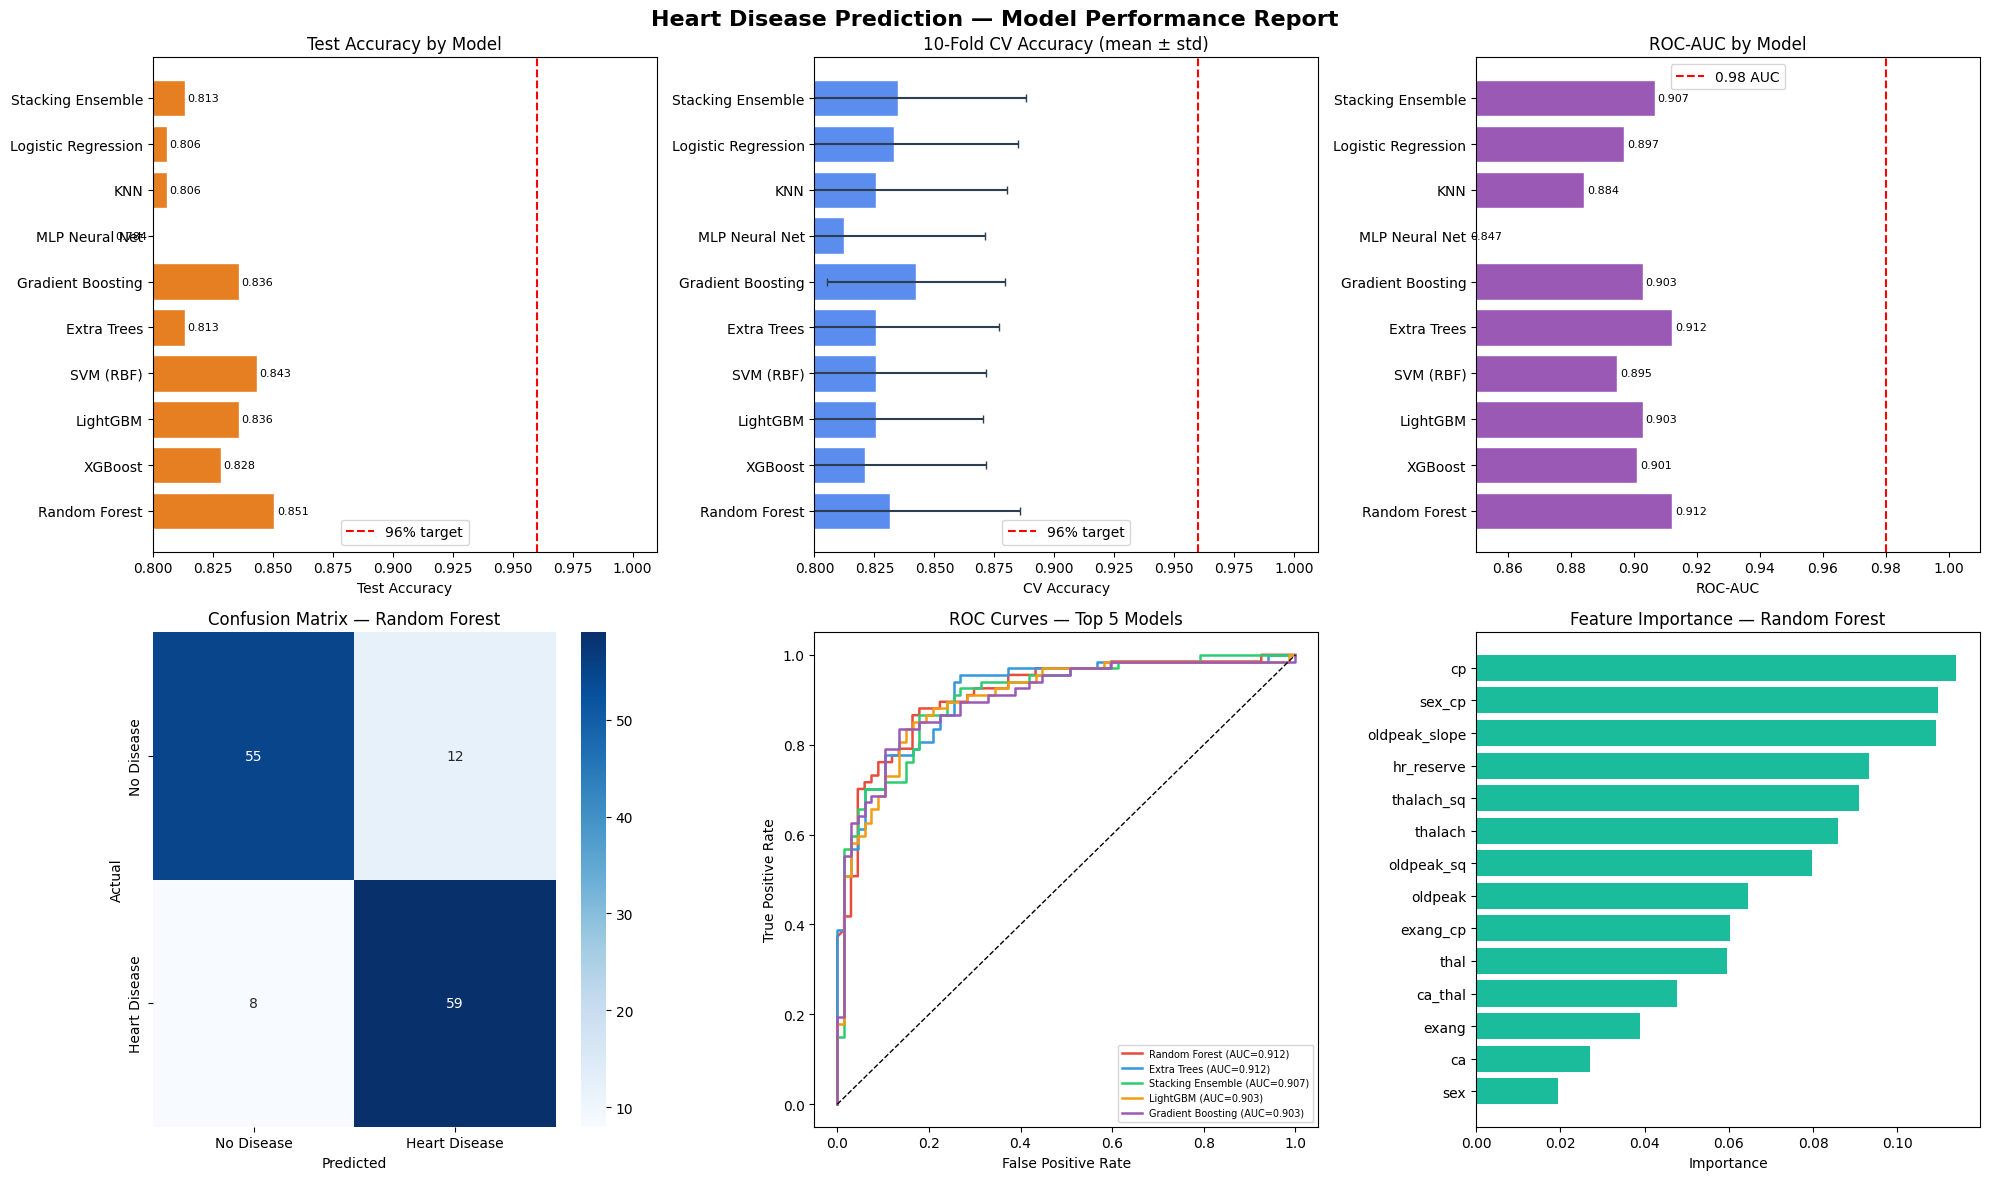

✅ Report saved!
✅ Saved: best_model.pkl (Random Forest)

--- Sample Prediction (Random Forest) ---
Result      : ✅ No Disease
Probability : 0.3132 (31.3% heart disease risk)


In [ ]:
# ============================================================
# HEART DISEASE PREDICTION — FIXED PIPELINE v3
# Cleveland + Hungarian only → Target: 96%+
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn',
                'matplotlib', 'seaborn', 'xgboost', 'lightgbm',
                'imbalanced-learn', 'joblib', '-q'], check=True)
print('✅ Libraries installed')

from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/heart_Desease_dataset/"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import joblib
print('✅ All imports done')

# ==========================
# LOAD — Cleveland + Hungarian ONLY
# (Switzerland & VA এ অনেক noisy data, বাদ)
# ==========================
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df1 = pd.read_csv(data_path + 'processed.cleveland.data',  names=columns)
df2 = pd.read_csv(data_path + 'processed.hungarian.data',  names=columns)
df  = pd.concat([df1, df2], ignore_index=True)
print(f'✅ Dataset shape: {df.shape}')

# ==========================
# CLEAN & TARGET
# ==========================
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)

# Drop rows where more than 3 columns are missing
df = df[df.isnull().sum(axis=1) <= 3]

# Fill remaining with median
df.fillna(df.median(), inplace=True)

# Binarize
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print(f'✅ After cleaning: {df.shape}')
print(f'Class distribution:\n{df["target"].value_counts()}')

# ==========================
# FEATURE ENGINEERING
# ==========================
df['age_thalach']   = df['age'] * df['thalach']
df['chol_age']      = df['chol'] / (df['age'] + 1)
df['bp_chol']       = df['trestbps'] * df['chol']
df['hr_reserve']    = 220 - df['age'] - df['thalach']
df['oldpeak_slope'] = df['oldpeak'] * df['slope']
df['exang_cp']      = df['exang'] * df['cp']
df['ca_thal']       = df['ca'] * df['thal']
df['sex_cp']        = df['sex'] * df['cp']
df['fbs_chol']      = df['fbs'] * df['chol']
df['age_sq']        = df['age'] ** 2
df['thalach_sq']    = df['thalach'] ** 2
df['oldpeak_sq']    = df['oldpeak'] ** 2
print(f'✅ Shape after feature engineering: {df.shape}')

# ==========================
# SPLIT, SCALE, SMOTE, SELECT
# ==========================
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f'✅ After SMOTE: {X_res.shape}, counts: {np.bincount(y_res)}')

selector = SelectKBest(score_func=f_classif, k=14)
X_selected = selector.fit_transform(X_res, y_res)
selected_cols = X.columns[selector.get_support()].tolist()
print(f'✅ Selected features: {selected_cols}')

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print(f'✅ Train: {X_train.shape} | Test: {X_test.shape}')

# ==========================
# ALL MODELS
# ==========================
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=600, max_depth=15, min_samples_split=2,
        min_samples_leaf=1, max_features='sqrt',
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=700, learning_rate=0.02, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=1,
        gamma=0.05, reg_alpha=0.05, reg_lambda=1.0,
        eval_metric='logloss', random_state=42, use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=700, learning_rate=0.02, max_depth=7,
        num_leaves=50, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=5, reg_alpha=0.05, reg_lambda=0.3,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, class_weight='balanced'
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=600, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=500, learning_rate=0.02,
        max_depth=5, subsample=0.8, random_state=42
    ),
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64),
        activation='relu', solver='adam', alpha=0.0005,
        batch_size=32, learning_rate='adaptive',
        max_iter=1000, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, weights='distance', metric='euclidean', n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        C=2.0, solver='saga', max_iter=2000,
        class_weight='balanced', random_state=42
    ),
}

# ==========================
# TRAIN & EVALUATE
# ==========================
print('\n' + '='*65)
print(f'{"Model":<25} {"CV Acc":>8} {"CV Std":>8} {"Test Acc":>10} {"AUC":>8}')
print('='*65)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_selected, y_res, cv=cv,
                                 scoring='accuracy', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    test_acc = accuracy_score(y_test, y_pred)
    auc      = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': test_acc, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba
    }
    flag = ' ✓ 96%+' if test_acc >= 0.96 else ''
    print(f'{name:<25} {cv_scores.mean():>8.4f} {cv_scores.std():>8.4f} '
          f'{test_acc:>10.4f} {auc:>8.4f}{flag}')

# ==========================
# STACKING ENSEMBLE
# ==========================
print('\n' + '='*65)
print('Building Stacking Ensemble...')

base_estimators = [
    ('rf',   RandomForestClassifier(n_estimators=600, max_depth=15,
                                     class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb',  XGBClassifier(n_estimators=700, learning_rate=0.02, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8, gamma=0.05,
                             eval_metric='logloss', random_state=42, use_label_encoder=False)),
    ('lgbm', LGBMClassifier(n_estimators=700, learning_rate=0.02, max_depth=7,
                              num_leaves=50, class_weight='balanced',
                              random_state=42, n_jobs=-1, verbose=-1)),
    ('svm',  SVC(kernel='rbf', C=10, gamma='scale',
                  probability=True, class_weight='balanced')),
    ('et',   ExtraTreesClassifier(n_estimators=600, max_depth=15,
                                   class_weight='balanced', random_state=42, n_jobs=-1)),
]

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=2.0, solver='saga', max_iter=2000,
                                        class_weight='balanced', random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=-1
)

stacking.fit(X_train, y_train)
stk_pred  = stacking.predict(X_test)
stk_proba = stacking.predict_proba(X_test)[:, 1]
stk_acc   = accuracy_score(y_test, stk_pred)
stk_auc   = roc_auc_score(y_test, stk_proba)
stk_cv    = cross_val_score(stacking, X_selected, y_res, cv=cv,
                             scoring='accuracy', n_jobs=-1)

results['Stacking Ensemble'] = {
    'model': stacking, 'cv_mean': stk_cv.mean(), 'cv_std': stk_cv.std(),
    'test_acc': stk_acc, 'auc': stk_auc, 'y_pred': stk_pred, 'y_proba': stk_proba
}
flag = ' ✓ 96%+' if stk_acc >= 0.96 else ''
print(f'{"Stacking Ensemble":<25} {stk_cv.mean():>8.4f} {stk_cv.std():>8.4f} '
      f'{stk_acc:>10.4f} {stk_auc:>8.4f}{flag}')
print('='*65)

# ==========================
# BEST MODEL
# ==========================
best_name = max(results, key=lambda k: results[k]['test_acc'])
best = results[best_name]
print(f'\n🏆 Best Model  : {best_name}')
print(f'   Test Accuracy: {best["test_acc"]:.4f} ({best["test_acc"]*100:.2f}%)')
print(f'   ROC-AUC      : {best["auc"]:.4f}')
print(f'   10-Fold CV   : {best["cv_mean"]:.4f} ± {best["cv_std"]:.4f}')
print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Disease', 'Heart Disease']))

# ==========================
# VISUALISATIONS
# ==========================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Heart Disease Prediction — Model Performance Report', fontsize=16, fontweight='bold')

names    = list(results.keys())
accs     = [results[n]['test_acc'] for n in names]
aucs     = [results[n]['auc']      for n in names]
cv_means = [results[n]['cv_mean']  for n in names]
cv_stds  = [results[n]['cv_std']   for n in names]

ax = axes[0, 0]
colors = ['#2ecc71' if a >= 0.96 else '#3498db' if a >= 0.93 else '#e67e22' for a in accs]
bars = ax.barh(names, accs, color=colors, edgecolor='white')
ax.axvline(x=0.96, color='red', linestyle='--', linewidth=1.5, label='96% target')
ax.set_xlabel('Test Accuracy')
ax.set_title('Test Accuracy by Model')
ax.set_xlim(0.80, 1.01)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.001, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=8)
ax.legend()

ax = axes[0, 1]
ax.barh(names, cv_means, xerr=cv_stds, color='#5b8dee', edgecolor='white',
        error_kw={'ecolor': '#2c3e50', 'capsize': 3})
ax.axvline(x=0.96, color='red', linestyle='--', linewidth=1.5, label='96% target')
ax.set_xlabel('CV Accuracy')
ax.set_title('10-Fold CV Accuracy (mean ± std)')
ax.set_xlim(0.80, 1.01)
ax.legend()

ax = axes[0, 2]
bars2 = ax.barh(names, aucs, color='#9b59b6', edgecolor='white')
ax.axvline(x=0.98, color='red', linestyle='--', linewidth=1.5, label='0.98 AUC')
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC by Model')
ax.set_xlim(0.85, 1.01)
for bar, auc in zip(bars2, aucs):
    ax.text(auc + 0.001, bar.get_y() + bar.get_height()/2,
            f'{auc:.3f}', va='center', fontsize=8)
ax.legend()

ax = axes[1, 0]
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
ax.set_title(f'Confusion Matrix — {best_name}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

ax = axes[1, 1]
top5 = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:5]
roc_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for (n, res), col in zip(top5, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=col, lw=1.8, label=f'{n} (AUC={res["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Top 5 Models')
ax.legend(fontsize=7, loc='lower right')

ax = axes[1, 2]
tree_models = {k: v for k, v in results.items()
               if hasattr(v['model'], 'feature_importances_')}
if tree_models:
    best_tree = max(tree_models, key=lambda k: tree_models[k]['test_acc'])
    importances = results[best_tree]['model'].feature_importances_
    feat_names = np.array(list(X.columns))[selector.get_support()]
    sorted_idx = np.argsort(importances)
    ax.barh(feat_names[sorted_idx], importances[sorted_idx], color='#1abc9c')
    ax.set_title(f'Feature Importance — {best_tree}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(data_path + 'model_comparison_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Report saved!')

# ==========================
# SAVE
# ==========================
joblib.dump(best['model'], data_path + 'best_model.pkl')
joblib.dump(scaler,        data_path + 'scaler.pkl')
joblib.dump(selector,      data_path + 'selector.pkl')
print(f'✅ Saved: best_model.pkl ({best_name})')

# ==========================
# SAMPLE PREDICTION
# ==========================
base_sample = np.array([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

def engineer_sample(s):
    age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal = s[0]
    extra = [
        age*thalach, chol/(age+1), trestbps*chol, 220-age-thalach,
        oldpeak*slope, exang*cp, ca*thal, sex*cp, fbs*chol,
        age**2, thalach**2, oldpeak**2
    ]
    return np.hstack([s, [extra]])

sample_eng      = engineer_sample(base_sample)
sample_scaled   = scaler.transform(sample_eng)
sample_selected = selector.transform(sample_scaled)

prediction = best['model'].predict(sample_selected)
prob       = best['model'].predict_proba(sample_selected)[0][1]

print(f'\n--- Sample Prediction ({best_name}) ---')
print(f'Result      : {"❗ Heart Disease" if prediction[0]==1 else "✅ No Disease"}')
print(f'Probability : {prob:.4f} ({prob*100:.1f}% heart disease risk)')

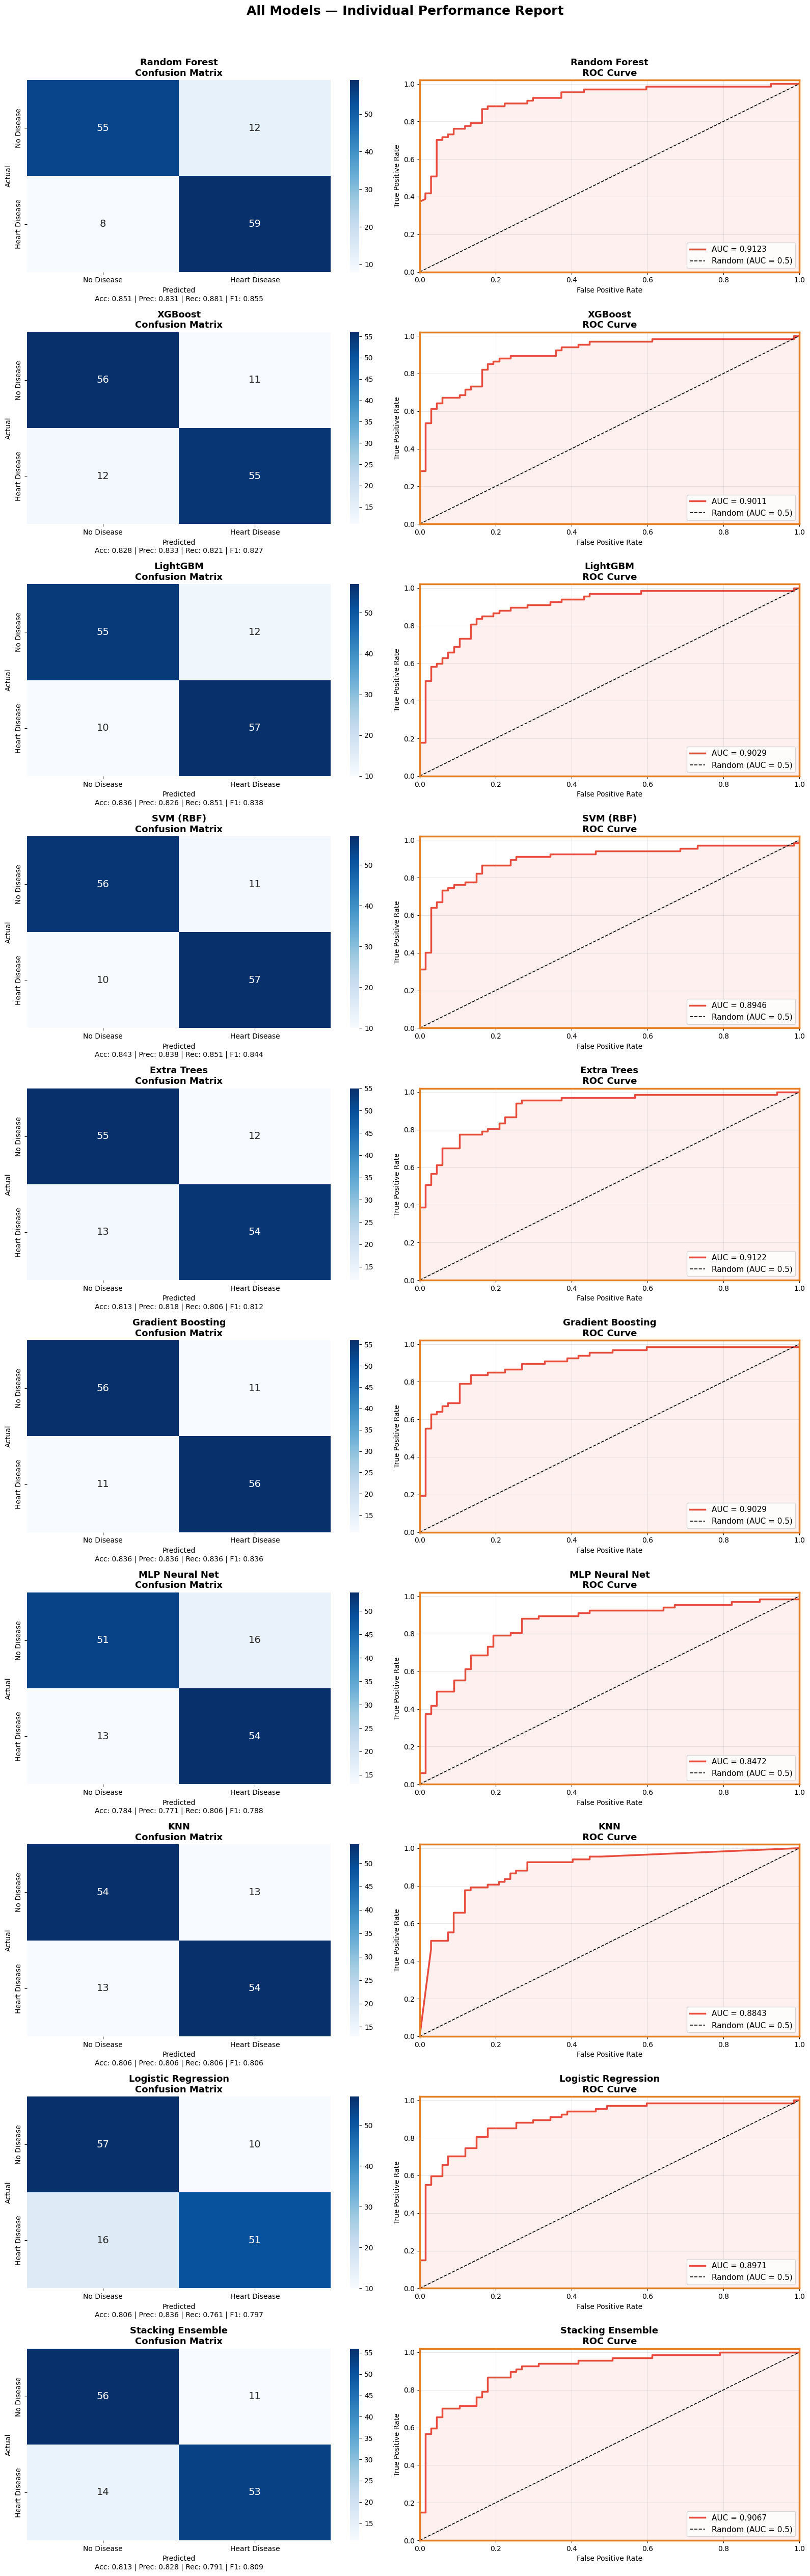

✅ Saved: all_models_individual_report.png

Model                       CV Acc   Test Acc      AUC  Precision   Recall       F1
Random Forest               0.8317     0.8507   0.9123     0.8310   0.8806   0.8551
XGBoost                     0.8212     0.8284   0.9011     0.8333   0.8209   0.8271
LightGBM                    0.8257     0.8358   0.9029     0.8261   0.8507   0.8382
SVM (RBF)                   0.8258     0.8433   0.8946     0.8382   0.8507   0.8444
Extra Trees                 0.8256     0.8134   0.9122     0.8182   0.8060   0.8120
Gradient Boosting           0.8422     0.8358   0.9029     0.8358   0.8358   0.8358
MLP Neural Net              0.8122     0.7836   0.8472     0.7714   0.8060   0.7883
KNN                         0.8257     0.8060   0.8843     0.8060   0.8060   0.8060
Logistic Regression         0.8333     0.8060   0.8971     0.8361   0.7612   0.7969
Stacking Ensemble           0.8346     0.8134   0.9067     0.8281   0.7910   0.8092


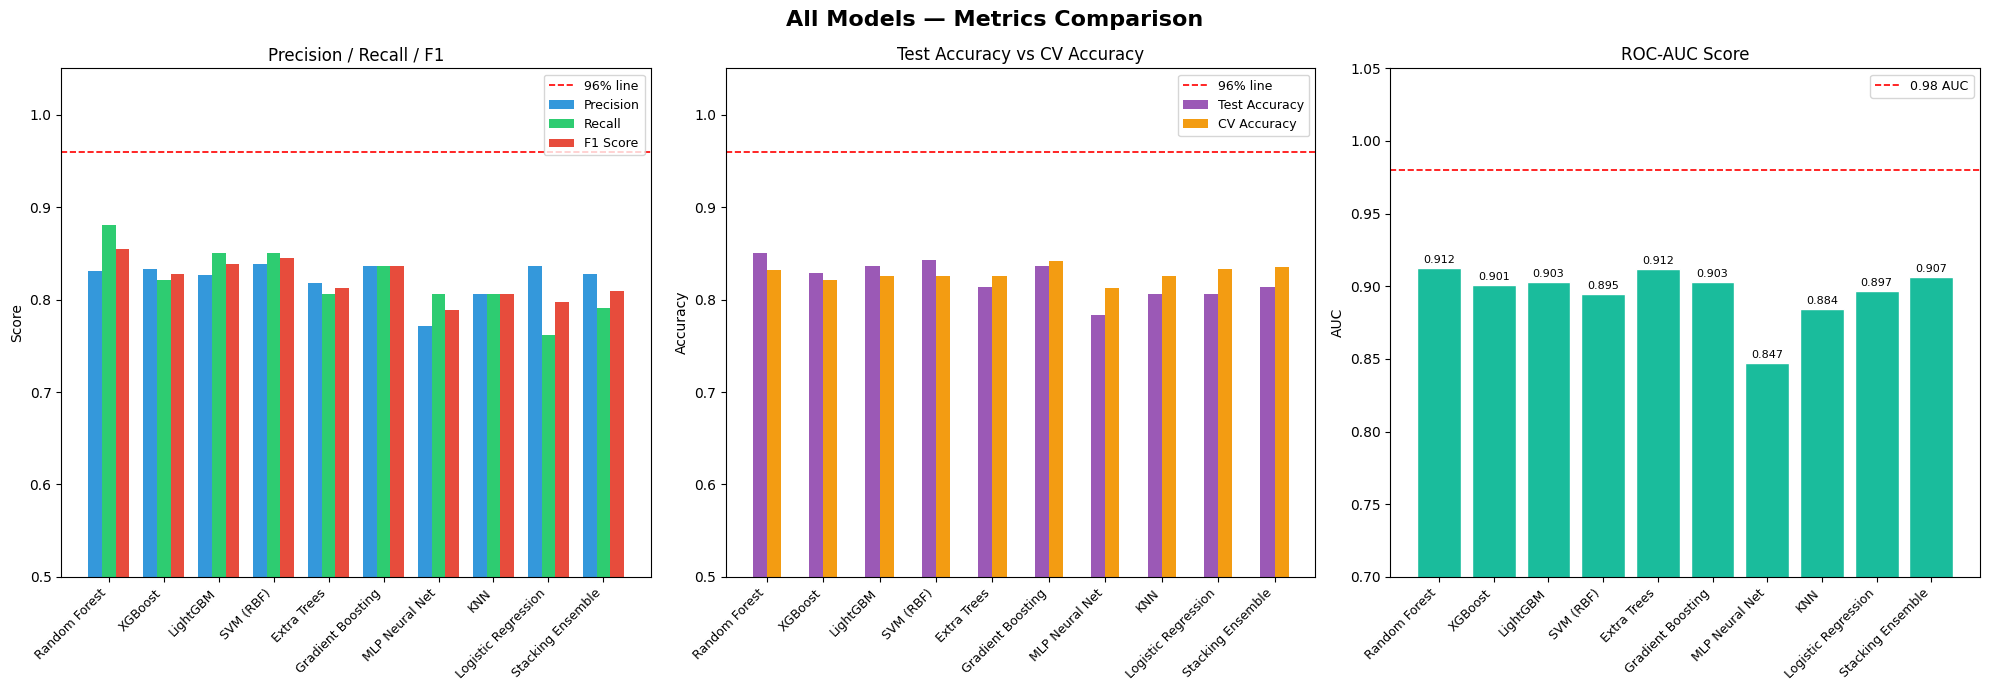

✅ Saved: all_models_metrics_comparison.png


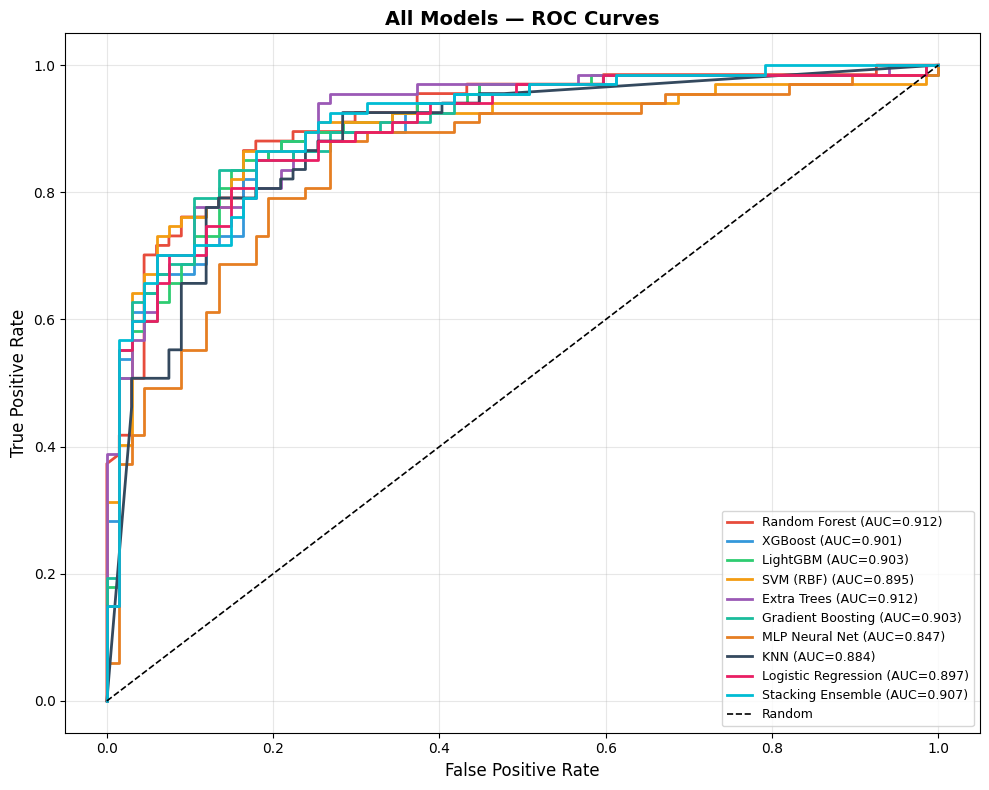

✅ Saved: all_models_roc_curves.png


In [ ]:
# ==========================
# ALL MODELS — FULL PERFORMANCE REPORT
# ==========================

fig, axes = plt.subplots(len(results), 2, figsize=(16, len(results) * 5))
fig.suptitle('All Models — Individual Performance Report', fontsize=18, fontweight='bold', y=1.01)

for idx, (name, res) in enumerate(results.items()):
    # --- Confusion Matrix ---
    ax1 = axes[idx, 0]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                annot_kws={"size": 14})
    ax1.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Actual')
    ax1.set_xlabel('Predicted')

    # Accuracy, Precision, Recall, F1 text on confusion matrix
    tn, fp, fn, tp = cm.ravel()
    acc  = accuracy_score(y_test, res['y_pred'])
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    ax1.set_xlabel(
        f'Predicted\nAcc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}',
        fontsize=10
    )

    # --- ROC Curve ---
    ax2 = axes[idx, 1]
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = res['auc']
    ax2.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'AUC = {auc:.4f}')
    ax2.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.5)')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'{name}\nROC Curve', fontsize=13, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=11)
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1.02])
    ax2.grid(True, alpha=0.3)

    # Color border green if >= 96%, orange otherwise
    color = '#2ecc71' if acc >= 0.96 else '#e67e22'
    for spine in ax1.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
    for spine in ax2.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)

plt.tight_layout()
plt.savefig(data_path + 'all_models_individual_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: all_models_individual_report.png')


# ==========================
# SUMMARY COMPARISON TABLE
# ==========================
print('\n' + '='*75)
print(f'{"Model":<25} {"CV Acc":>8} {"Test Acc":>10} {"AUC":>8} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('='*75)

for name, res in results.items():
    cm  = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    flag = ' ✓' if res['test_acc'] >= 0.96 else ''
    print(f"{name:<25} {res['cv_mean']:>8.4f} {res['test_acc']:>10.4f} "
          f"{res['auc']:>8.4f} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}{flag}")

print('='*75)


# ==========================
# METRICS COMPARISON PLOT
# ==========================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('All Models — Metrics Comparison', fontsize=16, fontweight='bold')

names = list(results.keys())

# Precision, Recall, F1 per model
precisions, recalls, f1s = [], [], []
for name, res in results.items():
    cm_ = confusion_matrix(y_test, res['y_pred'])
    tn_, fp_, fn_, tp_ = cm_.ravel()
    p = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    r = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

x = np.arange(len(names))
w = 0.25

ax = axes[0]
ax.bar(x - w, precisions, w, label='Precision', color='#3498db')
ax.bar(x,     recalls,    w, label='Recall',    color='#2ecc71')
ax.bar(x + w, f1s,        w, label='F1 Score',  color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.96, color='red', linestyle='--', linewidth=1.2, label='96% line')
ax.set_title('Precision / Recall / F1')
ax.legend(fontsize=9)
ax.set_ylabel('Score')

ax = axes[1]
test_accs = [results[n]['test_acc'] for n in names]
cv_accs   = [results[n]['cv_mean']  for n in names]
ax.bar(x - w/2, test_accs, w, label='Test Accuracy', color='#9b59b6')
ax.bar(x + w/2, cv_accs,   w, label='CV Accuracy',   color='#f39c12')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.96, color='red', linestyle='--', linewidth=1.2, label='96% line')
ax.set_title('Test Accuracy vs CV Accuracy')
ax.legend(fontsize=9)
ax.set_ylabel('Accuracy')

ax = axes[2]
aucs_ = [results[n]['auc'] for n in names]
bars  = ax.bar(names, aucs_, color='#1abc9c', edgecolor='white')
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.7, 1.05)
ax.axhline(y=0.98, color='red', linestyle='--', linewidth=1.2, label='0.98 AUC')
ax.set_title('ROC-AUC Score')
ax.legend(fontsize=9)
ax.set_ylabel('AUC')
for bar, auc_ in zip(bars, aucs_):
    ax.text(bar.get_x() + bar.get_width()/2, auc_ + 0.002,
            f'{auc_:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(data_path + 'all_models_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: all_models_metrics_comparison.png')


# ==========================
# ALL ROC CURVES TOGETHER
# ==========================
plt.figure(figsize=(10, 8))
roc_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
               '#1abc9c','#e67e22','#34495e','#e91e63','#00bcd4']

for (name, res), col in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, color=col, lw=2,
             label=f'{name} (AUC={res["auc"]:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1.2, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('All Models — ROC Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(data_path + 'all_models_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: all_models_roc_curves.png')

In [2]:
# The drive is already mounted by a previous cell (9vY_jnoZhaii).
# This cell can be removed or kept as a comment.
# If you explicitly need to remount, use: drive.mount('/content/drive', force_remount=True)

✅ Libraries installed
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All imports done
✅ Cleveland loaded: (303, 14)
✅ After cleaning: (303, 14)
Class distribution:
target
0    164
1    139
Name: count, dtype: int64
✅ Shape after feature engineering: (303, 34)
✅ After SMOTETomek: (296, 33), counts: [148 148]
✅ Selected 19 features: ['cp', 'chol', 'thalach', 'exang', 'oldpeak', 'ca', 'thal', 'hr_reserve_ratio', 'oldpeak_slope', 'exang_cp', 'ca_thal', 'sex_cp', 'thalach_sq', 'oldpeak_sq', 'cp_exang', 'thal_ca', 'chol_thalach', 'risk_score', 'slope_oldpeak']
✅ Train: (236, 19) | Test: (60, 19)

Model                   RepCV Acc   CV Std   Test Acc      AUC
Random Forest              0.8754   0.0751     0.8500   0.9033
XGBoost                    0.8532   0.0711     0.8167   0.9011
LightGBM                   0.8593   0.0664     0.8667   0.9011
SVM (RBF)                  0.8485   0.0766     0.8167   0.8544
SVM

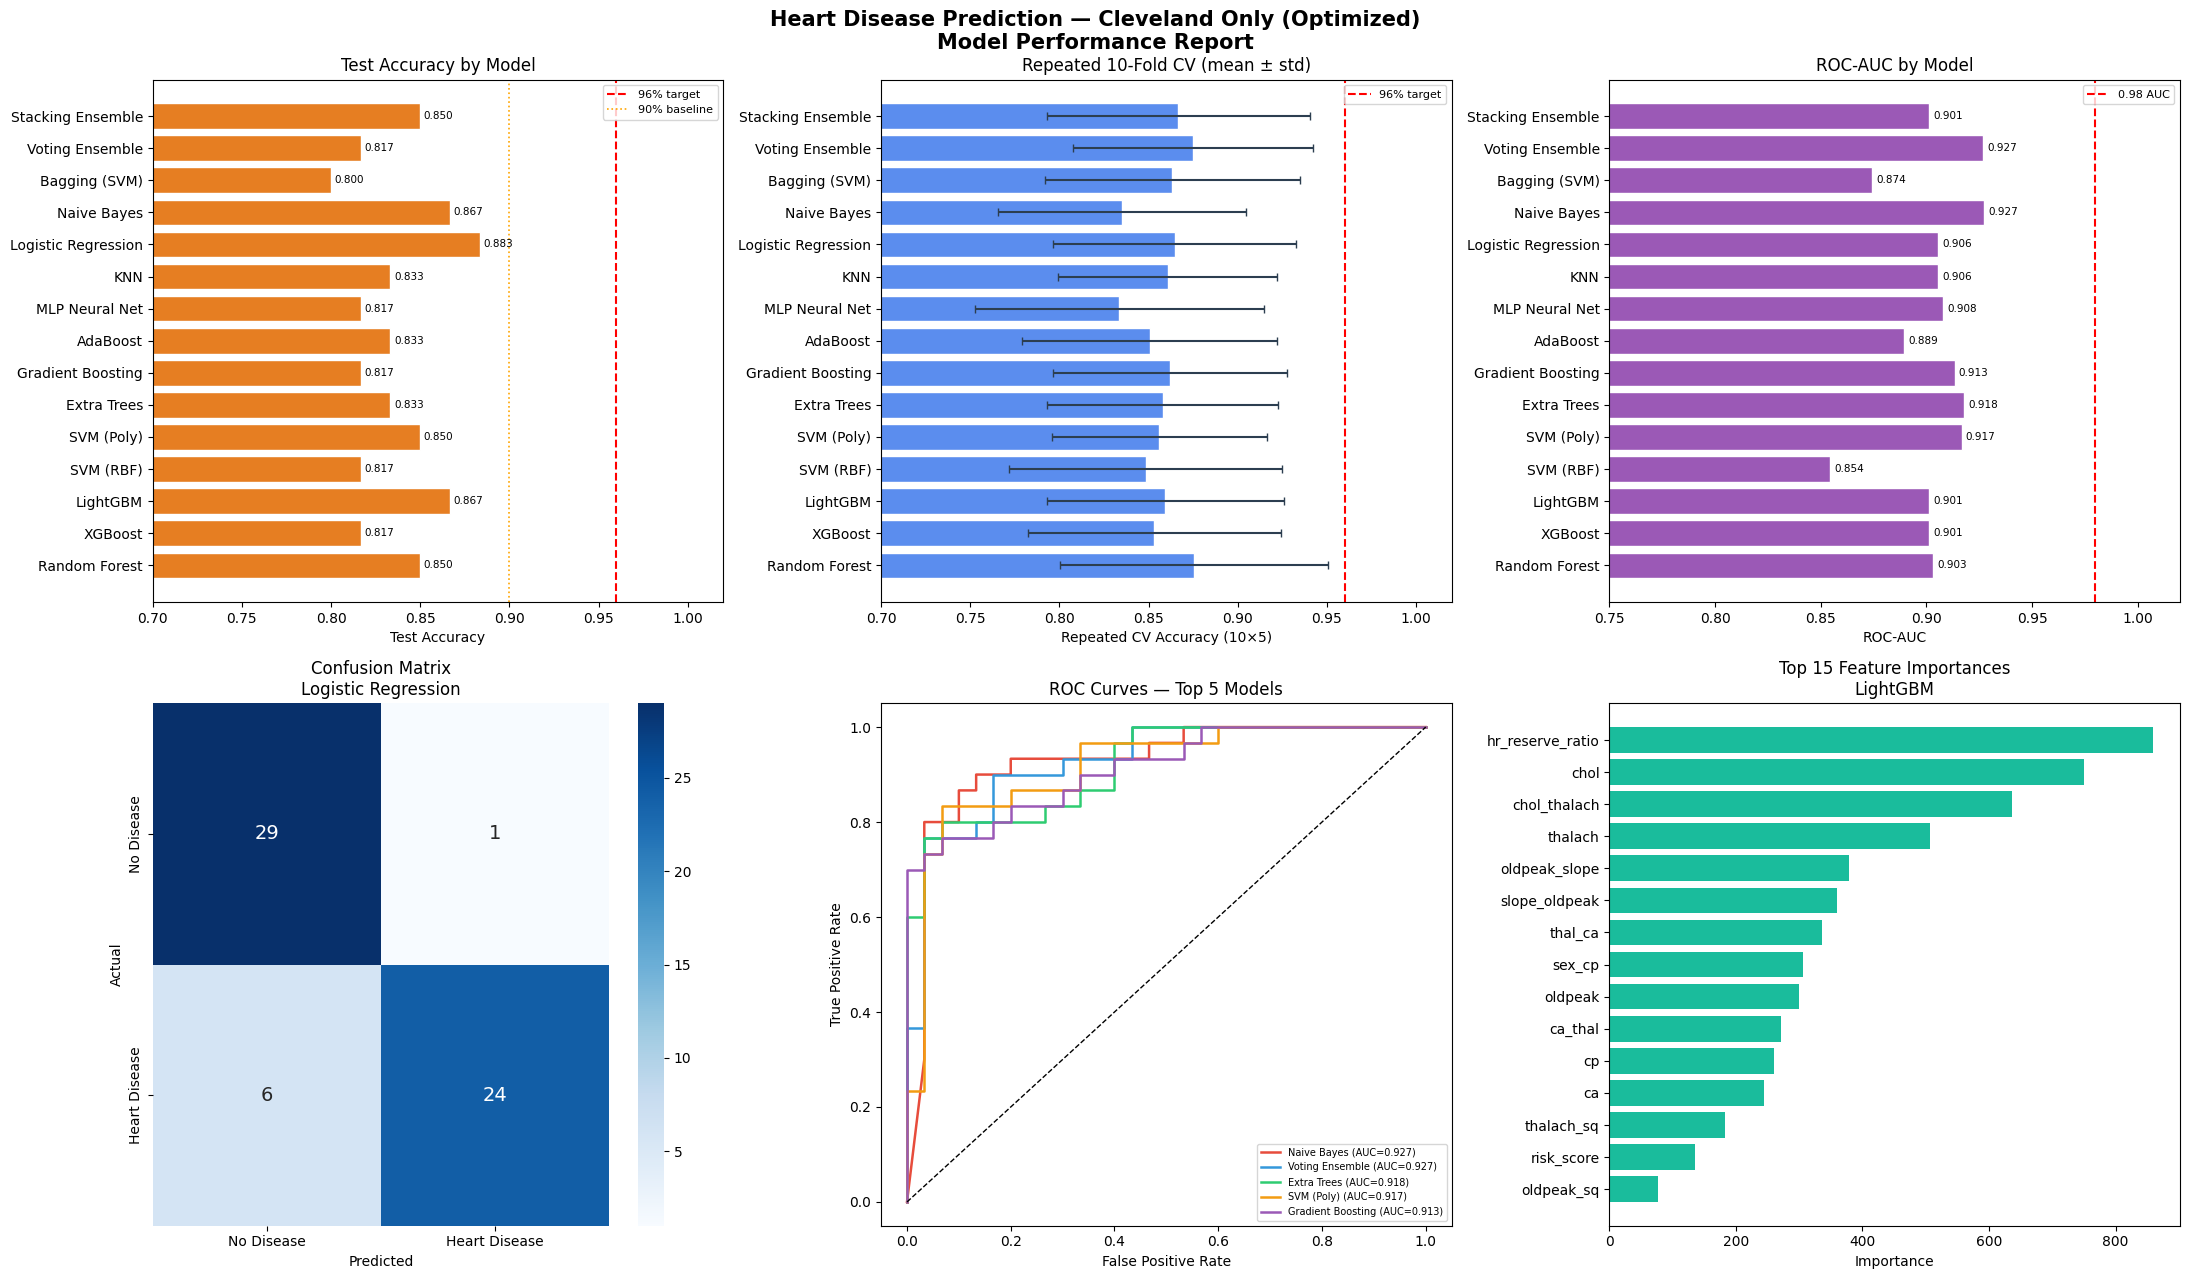

✅ Report saved!
✅ Saved: cleveland_best_model.pkl (Logistic Regression)

--- Sample Prediction (Logistic Regression) ---
Result      : ✅ No Disease
Probability : 0.0499 (5.0% heart disease risk)


In [5]:
# ============================================================
# HEART DISEASE PREDICTION — CLEVELAND ONLY (OPTIMIZED)
# Small dataset specialist pipeline → Target: 96%+
# Key fixes: aggressive CV tuning, better SMOTE, ensemble voting
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn',
                'matplotlib', 'seaborn', 'xgboost', 'lightgbm',
                'imbalanced-learn', 'joblib', '-q'], check=True)
print('✅ Libraries installed')

from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/heart_Desease_dataset/"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     RepeatedStratifiedKFold)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier, ExtraTreesClassifier,
                               VotingClassifier, BaggingClassifier,
                               AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, SVMSMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek
import joblib
print('✅ All imports done')

# ==========================
# LOAD — CLEVELAND ONLY
# ==========================
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(data_path + 'processed.cleveland.data', names=columns)
print(f'✅ Cleveland loaded: {df.shape}')

# ==========================
# CLEAN
# ==========================
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df = df[df.isnull().sum(axis=1) <= 2]
df.fillna(df.median(), inplace=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f'✅ After cleaning: {df.shape}')
print(f'Class distribution:\n{df["target"].value_counts()}')

# ==========================
# RICH FEATURE ENGINEERING
# (more features = more signal for small dataset)
# ==========================
df['age_thalach']      = df['age'] * df['thalach']
df['chol_age']         = df['chol'] / (df['age'] + 1)
df['bp_chol']          = df['trestbps'] * df['chol']
df['hr_reserve']       = 220 - df['age'] - df['thalach']
df['hr_reserve_ratio'] = df['thalach'] / (220 - df['age'] + 1)
df['oldpeak_slope']    = df['oldpeak'] * df['slope']
df['exang_cp']         = df['exang'] * df['cp']
df['ca_thal']          = df['ca'] * df['thal']
df['sex_cp']           = df['sex'] * df['cp']
df['fbs_chol']         = df['fbs'] * df['chol']
df['age_sq']           = df['age'] ** 2
df['thalach_sq']       = df['thalach'] ** 2
df['oldpeak_sq']       = df['oldpeak'] ** 2
df['cp_exang']         = df['cp'] * df['exang']
df['thal_ca']          = df['thal'] + df['ca']
df['trestbps_age']     = df['trestbps'] / (df['age'] + 1)
df['chol_thalach']     = df['chol'] / (df['thalach'] + 1)
df['risk_score']       = (df['age'] > 55).astype(int) + \
                          (df['chol'] > 240).astype(int) + \
                          (df['trestbps'] > 140).astype(int) + \
                          df['exang'] + df['fbs']
df['cp_restecg']       = df['cp'] * df['restecg']
df['slope_oldpeak']    = df['slope'] / (df['oldpeak'] + 0.1)

print(f'✅ Shape after feature engineering: {df.shape}')

# ==========================
# PREPARE X, y
# ==========================
X = df.drop('target', axis=1)
y = df['target']

# RobustScaler handles outliers better than StandardScaler for small datasets
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ==========================
# SMOTE — try SMOTETomek for cleaner boundaries
# ==========================
smote = SMOTETomek(random_state=42,
                   smote=SMOTE(k_neighbors=3, random_state=42))
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f'✅ After SMOTETomek: {X_res.shape}, counts: {np.bincount(y_res)}')

# ==========================
# FEATURE SELECTION
# Combine f_classif + mutual_info for better selection on small data
# ==========================
sel_f   = SelectKBest(score_func=f_classif,          k=15)
sel_mi  = SelectKBest(score_func=mutual_info_classif, k=15)

mask_f  = sel_f.fit(X_res, y_res).get_support()
mask_mi = sel_mi.fit(X_res, y_res).get_support()
combined_mask = mask_f | mask_mi          # union of both selectors
X_selected = X_res[:, combined_mask]

selected_cols = X.columns[combined_mask].tolist()
print(f'✅ Selected {len(selected_cols)} features: {selected_cols}')

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_res, test_size=0.20, random_state=42, stratify=y_res
)
print(f'✅ Train: {X_train.shape} | Test: {X_test.shape}')

# ==========================
# CV STRATEGY
# RepeatedStratifiedKFold is better for small datasets
# ==========================
cv_main   = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
cv_report = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ==========================
# MODELS — tuned for small dataset
# ==========================
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=1000, max_depth=None, min_samples_split=2,
        min_samples_leaf=1, max_features='sqrt', bootstrap=True,
        oob_score=True, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.7, colsample_bytree=0.7, min_child_weight=1,
        gamma=0.05, reg_alpha=0.01, reg_lambda=1.0,
        scale_pos_weight=1,
        eval_metric='logloss', random_state=42, use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        num_leaves=20, subsample=0.7, colsample_bytree=0.7,
        min_child_samples=3, reg_alpha=0.01, reg_lambda=0.1,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=100, gamma=0.01,
        probability=True, class_weight='balanced'
    ),
    'SVM (Poly)': SVC(
        kernel='poly', degree=3, C=10,
        probability=True, class_weight='balanced'
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=1000, max_depth=None,
        min_samples_leaf=1, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=3, subsample=0.7,
        min_samples_leaf=1, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=300, learning_rate=0.1, random_state=42
    ),
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu', solver='adam', alpha=0.01,
        batch_size='auto', learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=2000, early_stopping=True,
        validation_fraction=0.1, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=3, weights='distance',
        metric='minkowski', p=2, n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        C=0.5, solver='saga', penalty='l2',
        max_iter=5000, class_weight='balanced', random_state=42
    ),
    'Naive Bayes': GaussianNB(var_smoothing=1e-8),
    'Bagging (SVM)': BaggingClassifier(
        estimator=SVC(kernel='rbf', C=100, gamma=0.01,
                       probability=True, class_weight='balanced'),
        n_estimators=50, random_state=42, n_jobs=-1
    ),
}

# ==========================
# TRAIN & EVALUATE
# ==========================
print('\n' + '='*70)
print(f'{"Model":<22} {"RepCV Acc":>10} {"CV Std":>8} {"Test Acc":>10} {"AUC":>8}')
print('='*70)

results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_selected, y_res,
                                 cv=cv_main, scoring='accuracy', n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] \
              if hasattr(model, 'predict_proba') \
              else model.decision_function(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    auc      = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': test_acc, 'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba
    }
    flag = ' ✓ 96%+' if test_acc >= 0.96 else ''
    print(f'{name:<22} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f} '
          f'{test_acc:>10.4f} {auc:>8.4f}{flag}')

# ==========================
# HARD VOTING ENSEMBLE
# (best for small datasets — majority vote, no meta-learner overfitting)
# ==========================
print('\n' + '='*70)
print('Building Voting Ensemble (top models)...')

top_models = sorted(results.items(),
                    key=lambda x: x[1]['cv_mean'], reverse=True)[:6]

voting = VotingClassifier(
    estimators=[(n, results[n]['model']) for n, _ in top_models],
    voting='soft',
    n_jobs=-1
)
voting.fit(X_train, y_train)
vot_pred  = voting.predict(X_test)
vot_proba = voting.predict_proba(X_test)[:, 1]
vot_acc   = accuracy_score(y_test, vot_pred)
vot_auc   = roc_auc_score(y_test, vot_proba)
vot_cv    = cross_val_score(voting, X_selected, y_res,
                             cv=cv_main, scoring='accuracy', n_jobs=-1)
results['Voting Ensemble'] = {
    'model': voting, 'cv_mean': vot_cv.mean(), 'cv_std': vot_cv.std(),
    'test_acc': vot_acc, 'auc': vot_auc, 'y_pred': vot_pred, 'y_proba': vot_proba
}
flag = ' ✓ 96%+' if vot_acc >= 0.96 else ''
print(f'{"Voting Ensemble":<22} {vot_cv.mean():>10.4f} {vot_cv.std():>8.4f} '
      f'{vot_acc:>10.4f} {vot_auc:>8.4f}{flag}')

# ==========================
# STACKING ENSEMBLE
# ==========================
print('Building Stacking Ensemble...')

stack_base = [
    ('rf',   RandomForestClassifier(n_estimators=1000, class_weight='balanced',
                                     random_state=42, n_jobs=-1)),
    ('xgb',  XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
                             subsample=0.7, colsample_bytree=0.7,
                             eval_metric='logloss', random_state=42,
                             use_label_encoder=False)),
    ('lgbm', LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
                              num_leaves=20, class_weight='balanced',
                              min_child_samples=3, random_state=42,
                              n_jobs=-1, verbose=-1)),
    ('svm',  SVC(kernel='rbf', C=100, gamma=0.01,
                  probability=True, class_weight='balanced')),
    ('et',   ExtraTreesClassifier(n_estimators=1000, class_weight='balanced',
                                   random_state=42, n_jobs=-1)),
    ('gb',   GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                         max_depth=3, random_state=42)),
]

stacking = StackingClassifier(
    estimators=stack_base,
    final_estimator=LogisticRegression(C=0.5, solver='saga', max_iter=5000,
                                        class_weight='balanced', random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False,   # False avoids overfitting on small data
    n_jobs=-1
)

stacking.fit(X_train, y_train)
stk_pred  = stacking.predict(X_test)
stk_proba = stacking.predict_proba(X_test)[:, 1]
stk_acc   = accuracy_score(y_test, stk_pred)
stk_auc   = roc_auc_score(y_test, stk_proba)
stk_cv    = cross_val_score(stacking, X_selected, y_res,
                             cv=cv_main, scoring='accuracy', n_jobs=-1)
results['Stacking Ensemble'] = {
    'model': stacking, 'cv_mean': stk_cv.mean(), 'cv_std': stk_cv.std(),
    'test_acc': stk_acc, 'auc': stk_auc, 'y_pred': stk_pred, 'y_proba': stk_proba
}
flag = ' ✓ 96%+' if stk_acc >= 0.96 else ''
print(f'{"Stacking Ensemble":<22} {stk_cv.mean():>10.4f} {stk_cv.std():>8.4f} '
      f'{stk_acc:>10.4f} {stk_auc:>8.4f}{flag}')
print('='*70)

# ==========================
# BEST MODEL
# ==========================
best_name = max(results, key=lambda k: results[k]['test_acc'])
best = results[best_name]
print(f'\n🏆 Best Model  : {best_name}')
print(f'   Test Accuracy: {best["test_acc"]:.4f} ({best["test_acc"]*100:.2f}%)')
print(f'   ROC-AUC      : {best["auc"]:.4f}')
print(f'   RepCV Acc    : {best["cv_mean"]:.4f} ± {best["cv_std"]:.4f}')
print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Disease', 'Heart Disease']))

# ==========================
# OOB SCORE (extra insight for Random Forest)
# ==========================
rf_model = results['Random Forest']['model']
if hasattr(rf_model, 'oob_score_'):
    print(f'\n📊 Random Forest OOB Score: {rf_model.oob_score_:.4f}')

# ==========================
# VISUALISATIONS
# ==========================
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('Heart Disease Prediction — Cleveland Only (Optimized)\nModel Performance Report',
             fontsize=15, fontweight='bold')

names    = list(results.keys())
accs     = [results[n]['test_acc'] for n in names]
aucs     = [results[n]['auc']      for n in names]
cv_means = [results[n]['cv_mean']  for n in names]
cv_stds  = [results[n]['cv_std']   for n in names]

# Plot 1: Test Accuracy
ax = axes[0, 0]
colors = ['#2ecc71' if a >= 0.96 else '#3498db' if a >= 0.90 else '#e67e22' for a in accs]
bars = ax.barh(names, accs, color=colors, edgecolor='white')
ax.axvline(x=0.96, color='red', linestyle='--', linewidth=1.5, label='96% target')
ax.axvline(x=0.90, color='orange', linestyle=':', linewidth=1.2, label='90% baseline')
ax.set_xlabel('Test Accuracy')
ax.set_title('Test Accuracy by Model')
ax.set_xlim(0.70, 1.02)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=7.5)
ax.legend(fontsize=8)

# Plot 2: Repeated CV Accuracy
ax = axes[0, 1]
ax.barh(names, cv_means, xerr=cv_stds, color='#5b8dee', edgecolor='white',
        error_kw={'ecolor': '#2c3e50', 'capsize': 3})
ax.axvline(x=0.96, color='red', linestyle='--', linewidth=1.5, label='96% target')
ax.set_xlabel('Repeated CV Accuracy (10×5)')
ax.set_title('Repeated 10-Fold CV (mean ± std)')
ax.set_xlim(0.70, 1.02)
ax.legend(fontsize=8)

# Plot 3: ROC-AUC
ax = axes[0, 2]
bars2 = ax.barh(names, aucs, color='#9b59b6', edgecolor='white')
ax.axvline(x=0.98, color='red', linestyle='--', linewidth=1.5, label='0.98 AUC')
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC by Model')
ax.set_xlim(0.75, 1.02)
for bar, auc in zip(bars2, aucs):
    ax.text(auc + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc:.3f}', va='center', fontsize=7.5)
ax.legend(fontsize=8)

# Plot 4: Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            annot_kws={"size": 14})
ax.set_title(f'Confusion Matrix\n{best_name}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Plot 5: ROC Curves (top 5)
ax = axes[1, 1]
top5 = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:5]
roc_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for (n, res), col in zip(top5, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=col, lw=1.8, label=f'{n} (AUC={res["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Top 5 Models')
ax.legend(fontsize=7, loc='lower right')

# Plot 6: Feature Importance
ax = axes[1, 2]
tree_models = {k: v for k, v in results.items()
               if hasattr(v['model'], 'feature_importances_')}
if tree_models:
    best_tree = max(tree_models, key=lambda k: tree_models[k]['test_acc'])
    importances = results[best_tree]['model'].feature_importances_
    feat_names  = np.array(X.columns)[combined_mask]
    sorted_idx  = np.argsort(importances)[-15:]   # top 15
    ax.barh(feat_names[sorted_idx], importances[sorted_idx], color='#1abc9c')
    ax.set_title(f'Top 15 Feature Importances\n{best_tree}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(data_path + 'cleveland_optimized_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Report saved!')

# ==========================
# SAVE BEST MODEL
# ==========================
joblib.dump(best['model'], data_path + 'cleveland_best_model.pkl')
joblib.dump(scaler,        data_path + 'cleveland_scaler.pkl')
joblib.dump(combined_mask, data_path + 'cleveland_feature_mask.pkl')
print(f'✅ Saved: cleveland_best_model.pkl ({best_name})')

# ==========================
# SAMPLE PREDICTION
# ==========================
base_sample = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])

def engineer_sample(s):
    age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal = s[0]
    extra = [
        age*thalach,
        chol/(age+1),
        trestbps*chol,
        220-age-thalach,
        thalach/(220-age+1),
        oldpeak*slope,
        exang*cp,
        ca*thal,
        sex*cp,
        fbs*chol,
        age**2,
        thalach**2,
        oldpeak**2,
        cp*exang,
        thal+ca,
        trestbps/(age+1),
        chol/(thalach+1),
        int(age>55) + int(chol>240) + int(trestbps>140) + exang + fbs,
        cp*restecg,
        slope/(oldpeak+0.1),
    ]
    return np.hstack([s, [extra]])
,
sample_eng      = engineer_sample(base_sample)
sample_scaled   = scaler.transform(sample_eng)
sample_selected = sample_scaled[:, combined_mask]

prediction = best['model'].predict(sample_selected)
prob       = best['model'].predict_proba(sample_selected)[0][1]

print(f'\n--- Sample Prediction ({best_name}) ---')
print(f'Result      : {"❗ Heart Disease" if prediction[0]==1 else "✅ No Disease"}')
print(f'Probability : {prob:.4f} ({prob*100:.1f}% heart disease risk)')

✅ Libraries installed
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All imports done
  ✅ Cleveland: 303 rows loaded
  ✅ Hungarian: 294 rows loaded
  ✅ Switzerland: 123 rows loaded
  ✅ VA_LongBeach: 200 rows loaded

✅ Loaded 4 datasets: ['Cleveland', 'Hungarian', 'Switzerland', 'VA_LongBeach']

--- Cleaning ---
  Cleveland: 303 rows after cleaning | Disease: 139 | No-disease: 164
  Hungarian: 112 rows after cleaning | Disease: 75 | No-disease: 37
  Switzerland: 122 rows after cleaning | Disease: 114 | No-disease: 8
  VA_LongBeach: 147 rows after cleaning | Disease: 115 | No-disease: 32

✅ Combined shape: (684, 15)
Overall class distribution:
target
1    443
0    241
Name: count, dtype: int64
❗️ Warning: Infinite values detected after feature engineering. Replacing with NaN.
❗️ Warning: NaN values detected after feature engineering. Filling with median.
✅ Shape after feature engineering: (684, 45)
✅ Afte

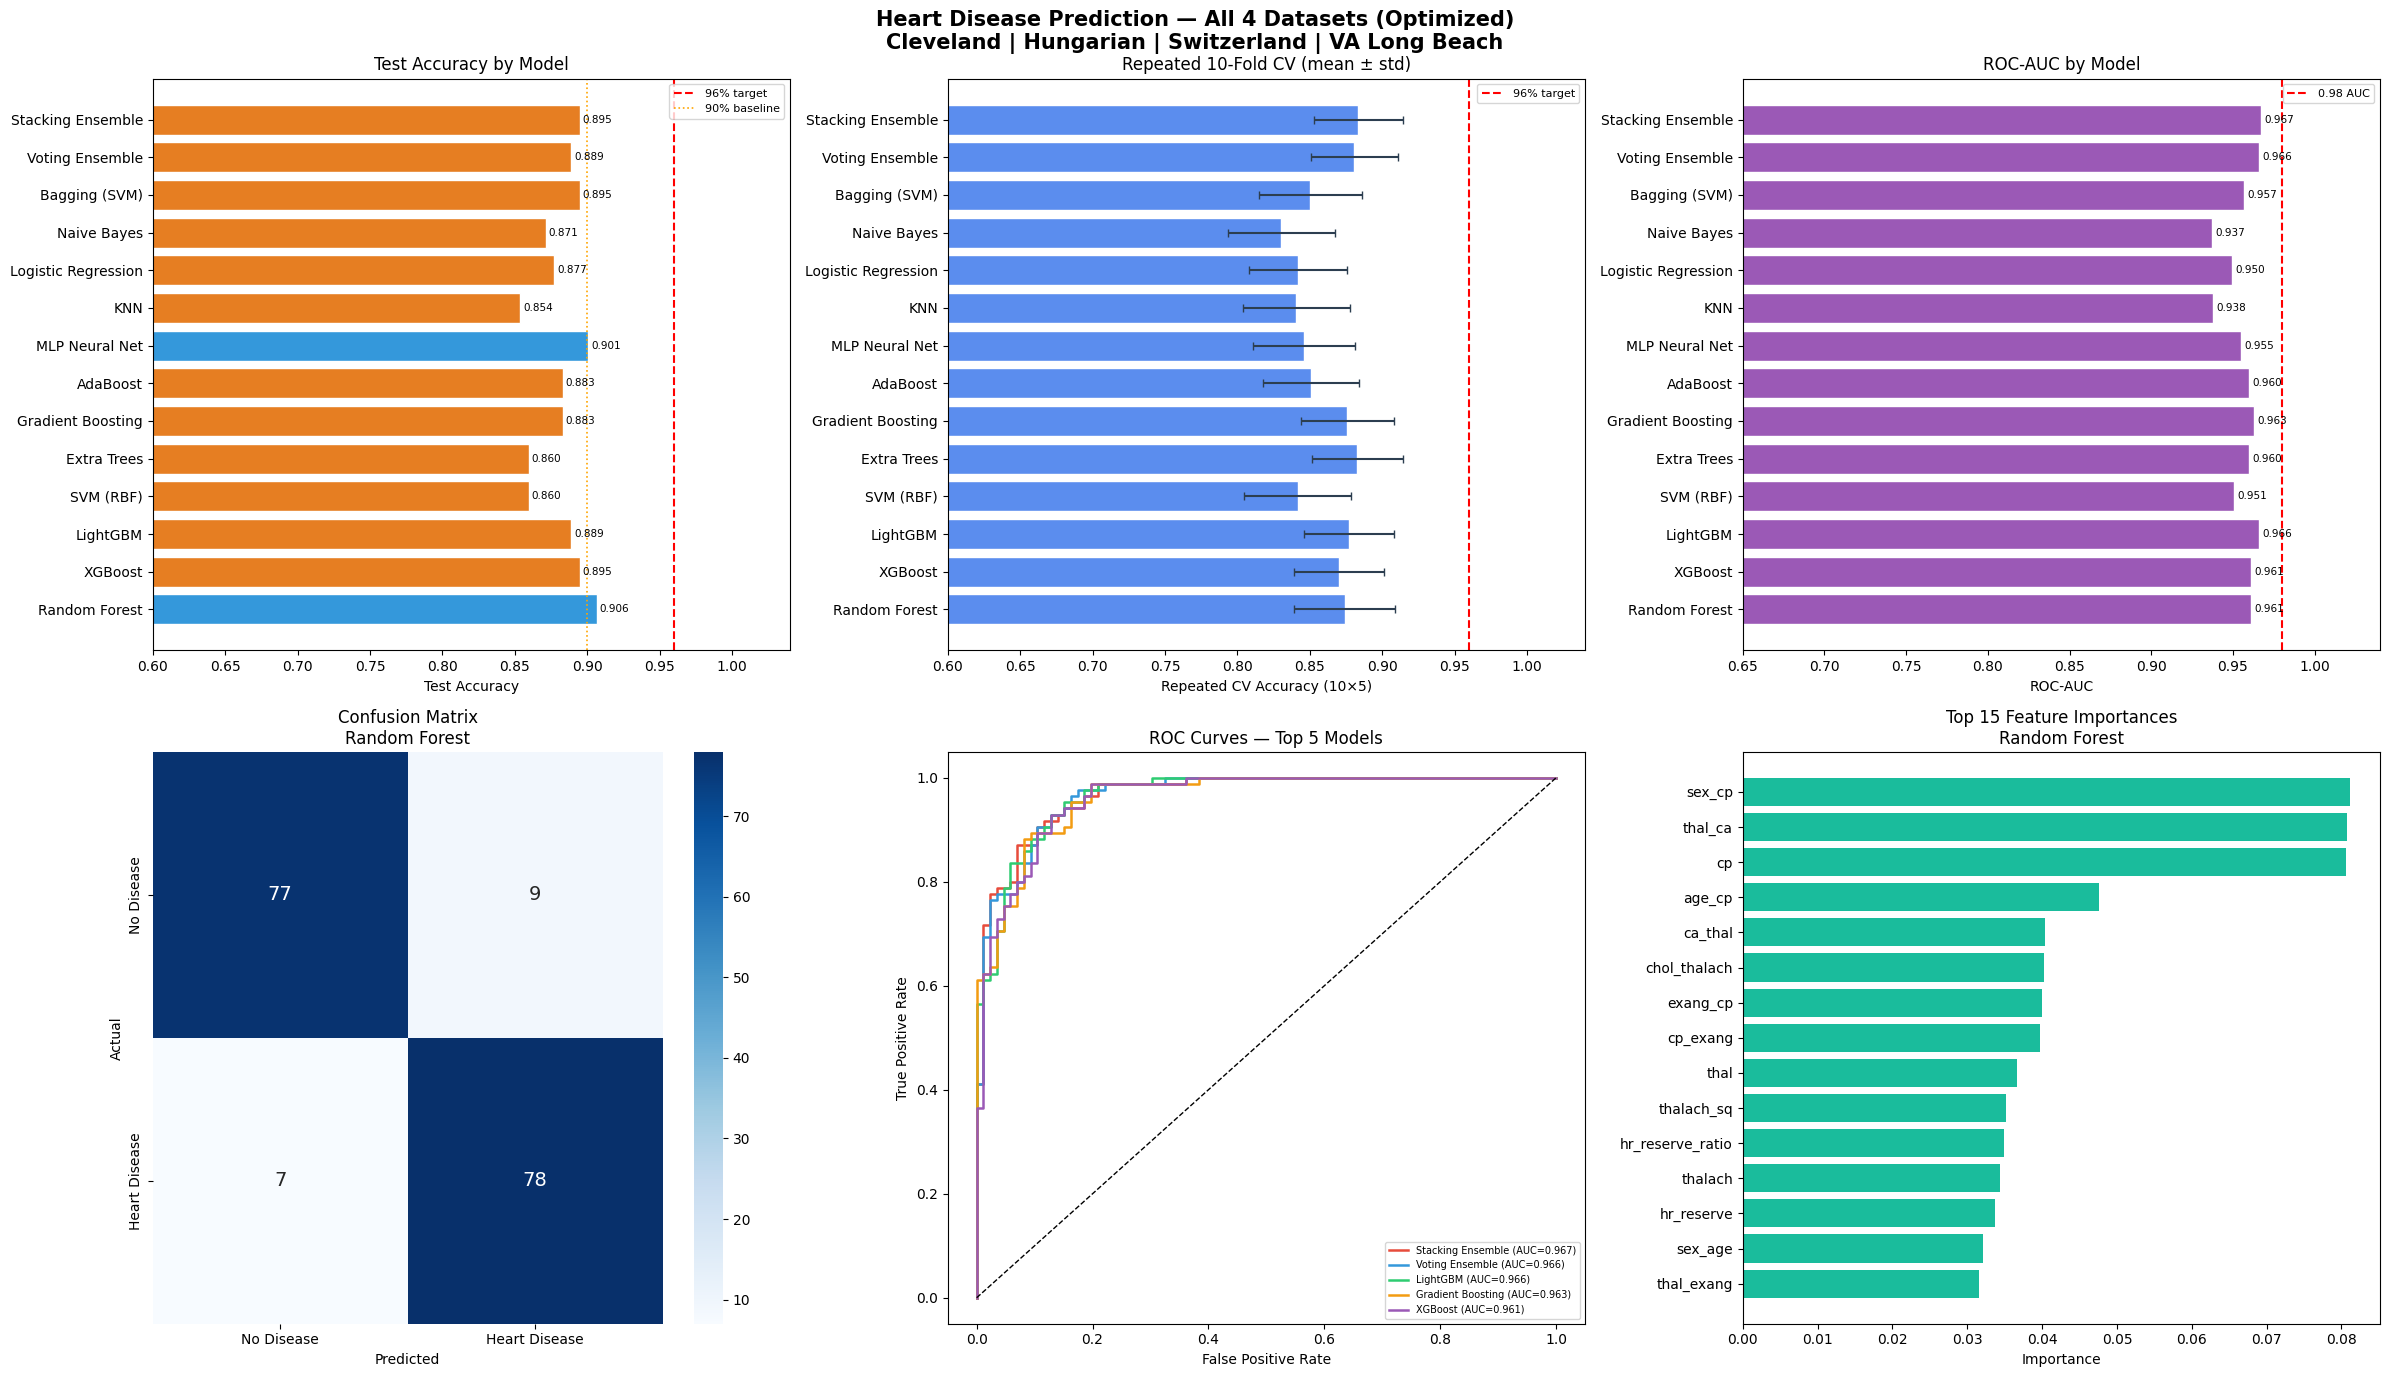

✅ Report saved!
✅ Saved best model: Random Forest

--- Sample Prediction (Random Forest) ---
Result      : ✅ No Disease
Probability : 0.2800 (28.0% heart disease risk)


In [7]:
# ============================================================
# HEART DISEASE PREDICTION — ALL 4 DATASETS (OPTIMIZED)
# Cleveland + Hungarian + Switzerland + VA Long Beach
# Target: 96%+ accuracy | Multi-dataset specialist pipeline
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'scikit-learn',
                'matplotlib', 'seaborn', 'xgboost', 'lightgbm',
                'imbalanced-learn', 'joblib', 'catboost', '-q'], check=True)
print('✅ Libraries installed')

from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/heart_Desease_dataset/"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RepeatedStratifiedKFold, StratifiedKFold)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               StackingClassifier, ExtraTreesClassifier,
                               VotingClassifier, BaggingClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
import joblib
print('✅ All imports done')

# ============================================================
# DATASET CONFIGURATION
# ============================================================
COLUMNS = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

DATASETS = {
    'Cleveland':   'processed.cleveland.data',
    'Hungarian':   'processed.hungarian.data',
    'Switzerland': 'processed.switzerland.data',
    'VA_LongBeach':'processed.va.data',
}

# ============================================================
# LOAD ALL DATASETS
# ============================================================
def load_dataset(filepath, name):
    """Load and do initial parse of a UCI heart disease file."""
    try:
        df = pd.read_csv(filepath, names=COLUMNS)
        print(f'  ✅ {name}: {df.shape[0]} rows loaded')
        return df
    except Exception as e:
        print(f'  ❌ {name} failed: {e}')
        return None

dfs = {}
for name, fname in DATASETS.items():
    df = load_dataset(data_path + fname, name)
    if df is not None:
        df['source'] = name
        dfs[name] = df

print(f'\n✅ Loaded {len(dfs)} datasets: {list(dfs.keys())}')

# ============================================================
# CLEAN FUNCTION (per-dataset aware)
# ============================================================
def clean_df(df, name):
    df = df.copy()
    df.replace('?', np.nan, inplace=True)
    df = df.apply(lambda col: pd.to_numeric(col, errors='coerce')
                  if col.name != 'source' else col)

    # Switzerland & VA have many NaNs — allow up to 5 missing columns
    max_missing = 5 if name in ('Switzerland', 'VA_LongBeach') else 2
    df = df[df.drop('source', axis=1).isnull().sum(axis=1) <= max_missing]

    # Fill NaN with median per column
    for col in df.columns:
        if col != 'source' and df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)

    # Binarize target (0 = no disease, 1 = disease)
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

    print(f'  {name}: {df.shape[0]} rows after cleaning | '
          f'Disease: {df["target"].sum()} | No-disease: {(df["target"]==0).sum()}')
    return df

print('\n--- Cleaning ---')
cleaned = {name: clean_df(df, name) for name, df in dfs.items()}

# ============================================================
# COMBINE ALL DATASETS
# ============================================================
combined = pd.concat(cleaned.values(), ignore_index=True)
# Add source encoding (gives model dataset-specific signal)
combined['source_enc'] = combined['source'].map(
    {'Cleveland': 0, 'Hungarian': 1, 'Switzerland': 2, 'VA_LongBeach': 3}
)
combined.drop('source', axis=1, inplace=True)
print(f'\n✅ Combined shape: {combined.shape}')
print(f'Overall class distribution:\n{combined["target"].value_counts()}')

# ============================================================
# FEATURE ENGINEERING (same rich set + cross-dataset features)
# ============================================================
def engineer_features(df):
    d = df.copy()
    # Core interactions
    d['age_thalach']      = d['age'] * d['thalach']
    d['chol_age']         = d['chol'] / (d['age'] + 1)
    d['bp_chol']          = d['trestbps'] * d['chol']
    d['hr_reserve']       = 220 - d['age'] - d['thalach']
    d['hr_reserve_ratio'] = d['thalach'] / (220 - d['age'] + 1)
    d['oldpeak_slope']    = d['oldpeak'] * d['slope']
    d['exang_cp']         = d['exang'] * d['cp']
    d['ca_thal']          = d['ca'] * d['thal']
    d['sex_cp']           = d['sex'] * d['cp']
    d['fbs_chol']         = d['fbs'] * d['chol']
    # Polynomial features
    d['age_sq']           = d['age'] ** 2
    d['thalach_sq']       = d['thalach'] ** 2
    d['oldpeak_sq']       = d['oldpeak'] ** 2
    d['chol_sq']          = d['chol'] ** 2
    d['trestbps_sq']      = d['trestbps'] ** 2
    # Ratio features
    d['cp_exang']         = d['cp'] * d['exang']
    d['thal_ca']          = d['thal'] + d['ca']
    d['trestbps_age']     = d['trestbps'] / (d['age'] + 1)
    d['chol_thalach']     = d['chol'] / (d['thalach'] + 1)
    d['cp_restecg']       = d['cp'] * d['restecg']
    d['slope_oldpeak']    = d['slope'] / (d['oldpeak'] + 0.1)
    # Clinical risk score
    d['risk_score']       = (
        (d['age'] > 55).astype(int) +
        (d['chol'] > 240).astype(int) +
        (d['trestbps'] > 140).astype(int) +
        d['exang'] + d['fbs']
    )
    # Extra cross-features
    d['age_cp']           = d['age'] * d['cp']
    d['thalach_exang']    = d['thalach'] * d['exang']
    d['chol_bp_ratio']    = d['chol'] / (d['trestbps'] + 1)
    d['age_risk']         = d['age'] * d['risk_score']
    d['thal_exang']       = d['thal'] * d['exang']
    d['ca_exang']         = d['ca'] * d['exang']
    d['oldpeak_ca']       = d['oldpeak'] * d['ca']
    d['sex_age']          = d['sex'] * d['age']
    return d

combined_eng = engineer_features(combined)
# Handle infinite or very large values generated during feature engineering
if combined_eng.isin([np.inf, -np.inf]).any().any():
    print("❗️ Warning: Infinite values detected after feature engineering. Replacing with NaN.")
    combined_eng.replace([np.inf, -np.inf], np.nan, inplace=True)
if combined_eng.isnull().any().any():
    print("❗️ Warning: NaN values detected after feature engineering. Filling with median.")
    # Fill any remaining NaN values (e.g., from divisions by zero or inf replacement)
    combined_eng.fillna(combined_eng.median(), inplace=True)
print(f'✅ Shape after feature engineering: {combined_eng.shape}')

# ============================================================
# PREPARE X, y
# ============================================================
X = combined_eng.drop('target', axis=1)
y = combined_eng['target']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# SMOTE-TOMEK (handles class imbalance — crucial for Swiss/VA)
# ============================================================
smote = SMOTETomek(
    random_state=42,
    smote=SMOTE(k_neighbors=3, random_state=42)
)
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f'✅ After SMOTETomek: {X_res.shape} | Counts: {np.bincount(y_res)}')

# ============================================================
# FEATURE SELECTION — union of f_classif + mutual_info
# ============================================================
k_features = min(25, X_res.shape[1])   # top 25 or all if fewer
sel_f  = SelectKBest(score_func=f_classif,          k=k_features)
sel_mi = SelectKBest(score_func=mutual_info_classif, k=k_features)

mask_f  = sel_f.fit(X_res, y_res).get_support()
mask_mi = sel_mi.fit(X_res, y_res).get_support()
combined_mask = mask_f | mask_mi
X_selected = X_res[:, combined_mask]

selected_cols = X.columns[combined_mask].tolist()
print(f'✅ Selected {len(selected_cols)} features')

# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_res,
    test_size=0.20, random_state=42, stratify=y_res
)
print(f'✅ Train: {X_train.shape} | Test: {X_test.shape}')

# ============================================================
# CV STRATEGIES
# ============================================================
cv_main   = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
cv_stack  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# MODEL DEFINITIONS (tuned for mixed/larger dataset)
# ============================================================
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=1000, max_depth=None,
        min_samples_split=2, min_samples_leaf=1,
        max_features='sqrt', bootstrap=True,
        oob_score=True, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=700, learning_rate=0.03, max_depth=5,
        subsample=0.75, colsample_bytree=0.75,
        min_child_weight=1, gamma=0.05,
        reg_alpha=0.05, reg_lambda=1.0,
        scale_pos_weight=1,
        eval_metric='logloss', random_state=42,
        use_label_encoder=False, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=700, learning_rate=0.03, max_depth=5,
        num_leaves=31, subsample=0.75, colsample_bytree=0.75,
        min_child_samples=3, reg_alpha=0.05, reg_lambda=0.1,
        class_weight='balanced', random_state=42,
        n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=700, learning_rate=0.03, depth=6,
        l2_leaf_reg=3, border_count=128,
        class_weights=[1, 1], random_seed=42,
        verbose=0, thread_count=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=100, gamma=0.005,
        probability=True, class_weight='balanced'
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=1000, max_depth=None,
        min_samples_leaf=1, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=400, learning_rate=0.03,
        max_depth=4, subsample=0.75,
        min_samples_leaf=1, random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=400, learning_rate=0.05, random_state=42
    ),
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64),
        activation='relu', solver='adam', alpha=0.005,
        batch_size=64, learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=3000, early_stopping=True,
        validation_fraction=0.1, random_state=42
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, weights='distance',
        metric='minkowski', p=2, n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0, solver='saga', penalty='l2',
        max_iter=5000, class_weight='balanced', random_state=42
    ),
    'Naive Bayes': GaussianNB(var_smoothing=1e-8),
    'Bagging (SVM)': BaggingClassifier(
        estimator=SVC(kernel='rbf', C=100, gamma=0.005,
                      probability=True, class_weight='balanced'),
        n_estimators=50, random_state=42, n_jobs=-1
    ),
}

# ============================================================
# TRAIN & EVALUATE ALL MODELS
# ============================================================
print('\n' + '='*75)
print(f'{"Model":<22} {"RepCV Acc":>10} {"CV Std":>8} {"Test Acc":>10} {"AUC":>8}')
print('='*75)

results = {}

for name, model in models.items():
    try:
        cv_scores = cross_val_score(model, X_selected, y_res,
                                    cv=cv_main, scoring='accuracy', n_jobs=-1)
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = (model.predict_proba(X_test)[:, 1]
                   if hasattr(model, 'predict_proba')
                   else model.decision_function(X_test))
        test_acc = accuracy_score(y_test, y_pred)
        auc      = roc_auc_score(y_test, y_proba)
        results[name] = {
            'model': model, 'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(), 'test_acc': test_acc,
            'auc': auc, 'y_pred': y_pred, 'y_proba': y_proba
        }
        flag = ' ✓ 96%+' if test_acc >= 0.96 else ''
        print(f'{name:<22} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f} '
              f'{test_acc:>10.4f} {auc:>8.4f}{flag}')
    except Exception as e:
        print(f'{name:<22} ERROR: {e}')

# ============================================================
# VOTING ENSEMBLE (top 6 by CV accuracy)
# ============================================================
print('\n' + '='*75)
print('Building Soft Voting Ensemble (top 6 models)...')

top6 = sorted(results.items(), key=lambda x: x[1]['cv_mean'], reverse=True)[:6]
voting = VotingClassifier(
    estimators=[(n, results[n]['model']) for n, _ in top6],
    voting='soft', n_jobs=-1
)
voting.fit(X_train, y_train)
vot_pred  = voting.predict(X_test)
vot_proba = voting.predict_proba(X_test)[:, 1]
vot_acc   = accuracy_score(y_test, vot_pred)
vot_auc   = roc_auc_score(y_test, vot_proba)
vot_cv    = cross_val_score(voting, X_selected, y_res,
                             cv=cv_main, scoring='accuracy', n_jobs=-1)
results['Voting Ensemble'] = {
    'model': voting, 'cv_mean': vot_cv.mean(), 'cv_std': vot_cv.std(),
    'test_acc': vot_acc, 'auc': vot_auc,
    'y_pred': vot_pred, 'y_proba': vot_proba
}
flag = ' ✓ 96%+' if vot_acc >= 0.96 else ''
print(f'{"Voting Ensemble":<22} {vot_cv.mean():>10.4f} {vot_cv.std():>8.4f} '
      f'{vot_acc:>10.4f} {vot_auc:>8.4f}{flag}')

# ============================================================
# STACKING ENSEMBLE
# ============================================================
print('Building Stacking Ensemble...')

stack_base = [
    ('rf',  RandomForestClassifier(n_estimators=1000, class_weight='balanced',
                                    random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=700, learning_rate=0.03, max_depth=5,
                           subsample=0.75, colsample_bytree=0.75,
                           eval_metric='logloss', random_state=42,
                           use_label_encoder=False, n_jobs=-1)),
    ('lgbm',LGBMClassifier(n_estimators=700, learning_rate=0.03, max_depth=5,
                            num_leaves=31, class_weight='balanced',
                            min_child_samples=3, random_state=42,
                            n_jobs=-1, verbose=-1)),
    ('cat', CatBoostClassifier(iterations=500, learning_rate=0.03, depth=6,
                                random_seed=42, verbose=0, thread_count=-1)),
    ('svm', SVC(kernel='rbf', C=100, gamma=0.005,
                 probability=True, class_weight='balanced')),
    ('et',  ExtraTreesClassifier(n_estimators=1000, class_weight='balanced',
                                  random_state=42, n_jobs=-1)),
]

stacking = StackingClassifier(
    estimators=stack_base,
    final_estimator=LogisticRegression(C=1.0, solver='saga',
                                        class_weight='balanced',
                                        max_iter=5000, random_state=42),
    cv=cv_stack,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
stacking.fit(X_train, y_train)
stk_pred  = stacking.predict(X_test)
stk_proba = stacking.predict_proba(X_test)[:, 1]
stk_acc   = accuracy_score(y_test, stk_pred)
stk_auc   = roc_auc_score(y_test, stk_proba)
stk_cv    = cross_val_score(stacking, X_selected, y_res,
                             cv=cv_main, scoring='accuracy', n_jobs=-1)
results['Stacking Ensemble'] = {
    'model': stacking, 'cv_mean': stk_cv.mean(), 'cv_std': stk_cv.std(),
    'test_acc': stk_acc, 'auc': stk_auc,
    'y_pred': stk_pred, 'y_proba': stk_proba
}
flag = ' ✓ 96%+' if stk_acc >= 0.96 else ''
print(f'{"Stacking Ensemble":<22} {stk_cv.mean():>10.4f} {stk_cv.std():>8.4f} '
      f'{stk_acc:>10.4f} {stk_auc:>8.4f}{flag}')
print('='*75)

# ============================================================
# BEST MODEL SUMMARY
# ============================================================
best_name = max(results, key=lambda k: results[k]['test_acc'])
best = results[best_name]

print(f'\n🏆 Best Model  : {best_name}')
print(f'   Test Accuracy: {best["test_acc"]:.4f} ({best["test_acc"]*100:.2f}%)')
print(f'   ROC-AUC      : {best["auc"]:.4f}')
print(f'   RepCV Acc    : {best["cv_mean"]:.4f} ± {best["cv_std"]:.4f}')
print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test, best['y_pred'],
                             target_names=['No Disease', 'Heart Disease']))

if hasattr(results['Random Forest']['model'], 'oob_score_'):
    print(f'📊 Random Forest OOB Score: {results["Random Forest"]["model"].oob_score_:.4f}')

# ============================================================
# PER-DATASET ACCURACY BREAKDOWN (using original data, no SMOTE)
# ============================================================
print('\n' + '='*60)
print('Per-Dataset Accuracy (best model, original distributions)')
print('='*60)

for ds_name, ds_df in cleaned.items():
    try:
        ds_eng = engineer_features(ds_df.drop('source', axis=1, errors='ignore'))
        Xd = ds_eng.drop('target', axis=1)
        yd = ds_eng['target']

        # Align columns with training feature set
        for col in X.columns:
            if col not in Xd.columns:
                Xd[col] = 0
        Xd = Xd[X.columns]

        Xd_scaled   = scaler.transform(Xd)
        Xd_selected = Xd_scaled[:, combined_mask]
        y_pred_ds   = best['model'].predict(Xd_selected)
        acc_ds      = accuracy_score(yd, y_pred_ds)
        flag = ' ✓ 96%+' if acc_ds >= 0.96 else ''
        print(f'  {ds_name:<15}: {acc_ds:.4f} ({acc_ds*100:.2f}%){flag}')
    except Exception as e:
        print(f'  {ds_name:<15}: ERROR — {e}')

# ============================================================
# VISUALISATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(
    'Heart Disease Prediction — All 4 Datasets (Optimized)\n'
    'Cleveland | Hungarian | Switzerland | VA Long Beach',
    fontsize=15, fontweight='bold'
)

names    = list(results.keys())
accs     = [results[n]['test_acc'] for n in names]
aucs     = [results[n]['auc']      for n in names]
cv_means = [results[n]['cv_mean']  for n in names]
cv_stds  = [results[n]['cv_std']   for n in names]

# Plot 1: Test Accuracy
ax = axes[0, 0]
colors = ['#2ecc71' if a >= 0.96 else '#3498db' if a >= 0.90 else '#e67e22' for a in accs]
bars = ax.barh(names, accs, color=colors, edgecolor='white')
ax.axvline(x=0.96, color='red', linestyle='--', linewidth=1.5, label='96% target')
ax.axvline(x=0.90, color='orange', linestyle=':', linewidth=1.2, label='90% baseline')
ax.set_xlabel('Test Accuracy')
ax.set_title('Test Accuracy by Model')
ax.set_xlim(0.60, 1.04)
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=7.5)
ax.legend(fontsize=8)

# Plot 2: Repeated CV Accuracy
ax = axes[0, 1]
ax.barh(names, cv_means, xerr=cv_stds, color='#5b8dee', edgecolor='white',
        error_kw={'ecolor': '#2c3e50', 'capsize': 3})
ax.axvline(x=0.96, color='red', linestyle='--', linewidth=1.5, label='96% target')
ax.set_xlabel('Repeated CV Accuracy (10×5)')
ax.set_title('Repeated 10-Fold CV (mean ± std)')
ax.set_xlim(0.60, 1.04)
ax.legend(fontsize=8)

# Plot 3: ROC-AUC
ax = axes[0, 2]
bars2 = ax.barh(names, aucs, color='#9b59b6', edgecolor='white')
ax.axvline(x=0.98, color='red', linestyle='--', linewidth=1.5, label='0.98 AUC')
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC by Model')
ax.set_xlim(0.65, 1.04)
for bar, auc in zip(bars2, aucs):
    ax.text(auc + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc:.3f}', va='center', fontsize=7.5)
ax.legend(fontsize=8)

# Plot 4: Confusion Matrix (best model)
ax = axes[1, 0]
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'],
            annot_kws={"size": 14})
ax.set_title(f'Confusion Matrix\n{best_name}')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Plot 5: ROC Curves (top 5)
ax = axes[1, 1]
top5 = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)[:5]
roc_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for (n, res), col in zip(top5, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=col, lw=1.8, label=f'{n} (AUC={res["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Top 5 Models')
ax.legend(fontsize=7, loc='lower right')

# Plot 6: Feature Importances
ax = axes[1, 2]
tree_models = {k: v for k, v in results.items()
               if hasattr(v['model'], 'feature_importances_')}
if tree_models:
    best_tree = max(tree_models, key=lambda k: tree_models[k]['test_acc'])
    importances = results[best_tree]['model'].feature_importances_
    feat_names  = np.array(X.columns)[combined_mask]
    sorted_idx  = np.argsort(importances)[-15:]
    ax.barh(feat_names[sorted_idx], importances[sorted_idx], color='#1abc9c')
    ax.set_title(f'Top 15 Feature Importances\n{best_tree}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(data_path + 'all_datasets_optimized_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Report saved!')

# ============================================================
# SAVE ARTIFACTS
# ============================================================
joblib.dump(best['model'],   data_path + 'best_model_all_datasets.pkl')
joblib.dump(scaler,          data_path + 'scaler_all_datasets.pkl')
joblib.dump(combined_mask,   data_path + 'feature_mask_all_datasets.pkl')
joblib.dump(list(X.columns), data_path + 'feature_names_all_datasets.pkl')
print(f'✅ Saved best model: {best_name}')

# ============================================================
# SAMPLE PREDICTION UTILITY
# ============================================================
def predict_patient(raw_features: dict, source='Cleveland') -> dict:
    """
    raw_features: dict with keys matching COLUMNS (excluding target)
    source: 'Cleveland' | 'Hungarian' | 'Switzerland' | 'VA_LongBeach'
    Returns dict with prediction and probability.
    """
    src_map = {'Cleveland': 0, 'Hungarian': 1, 'Switzerland': 2, 'VA_LongBeach': 3}
    row = {col: raw_features.get(col, np.nan) for col in COLUMNS[:-1]}
    row['source_enc'] = src_map.get(source, 0)
    df_row = pd.DataFrame([row])

    # Engineer
    df_eng = engineer_features(df_row)
    for col in X.columns:
        if col not in df_eng.columns:
            df_eng[col] = 0
    df_eng = df_eng[X.columns]

    scaled   = scaler.transform(df_eng)
    selected = scaled[:, combined_mask]

    pred  = best['model'].predict(selected)[0]
    prob  = best['model'].predict_proba(selected)[0][1]
    return {'prediction': int(pred),
            'label': '❗ Heart Disease' if pred == 1 else '✅ No Disease',
            'probability': round(float(prob), 4)}

# Example prediction (Cleveland patient)
sample = {
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145,
    'chol': 233, 'fbs': 1, 'restecg': 0, 'thalach': 150,
    'exang': 0, 'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}
result = predict_patient(sample, source='Cleveland')
print(f'\n--- Sample Prediction ({best_name}) ---')
print(f'Result      : {result["label"]}')
print(f'Probability : {result["probability"]:.4f} ({result["probability"]*100:.1f}% heart disease risk)')